In [1]:
from google.colab import files
uploaded = files.upload()

Saving leomessi_matches.csv to leomessi_matches.csv


In [2]:
import pandas as pd


df = pd.read_csv("leomessi_matches.csv", na_values=["N/A"])


df.head()

,Unnamed: 0,Number,Date,Season,Competition,Round,Home/Away,Home Team,Home Score,Away Team,...,Shots on Target,Free Kick Attempts,Successful Dribbles,Key Passes,Big Chances Created,Accurate Throughballs,Aerial Duels Won,xG,xA,MOTM
0,0,1052,13/03/2024,23/24,CONCACAF Champions Cup,R16,H,Inter Miami,3,Nashville SC,...,1.0,1.0,1.0,1.0,1.0,NaN,0.0,NaN,NaN,Yes
1,1,1051,07/03/2024,23/24,CONCACAF Champions Cup,R16,A,Nashville SC,2,Inter Miami,...,2.0,1.0,2.0,3.0,0.0,NaN,1.0,NaN,NaN,No
2,2,1050,02/03/2024,23/24,MLS,NaN,H,Inter Miami,5,Orlando City,...,2.0,2.0,3.0,1.0,0.0,NaN,0.0,NaN,NaN,No
3,3,1049,25/02/2024,23/24,MLS,NaN,A,LA Galaxy,1,Inter Miami,...,3.0,1.0,1.0,1.0,0.0,NaN,0.0,NaN,NaN,No
4,4,1048,21/02/2024,23/24,MLS,NaN,H,Inter Miami,2,Real Salt Lake,...,2.0,1.0,1.0,5.0,0.0,NaN,0.0,NaN,NaN,No


In [3]:
df.shape

(1052, 26)

In [4]:

if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)


df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")


numeric_columns = [
    "Goals", "Assists", "Minutes Played", "Match Rating",
    "Shots", "Shots on Target", "Free Kick Attempts",
    "Successful Dribbles", "Key Passes", "Big Chances Created",
    "Accurate Throughballs", "Aerial Duels Won"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")


df.isnull().sum()

,0
Number,0
Date,0
Season,0
Competition,0
Round,706
Home/Away,0
Home Team,0
Home Score,0
Away Team,0
Away Score,0


In [5]:

df = pd.read_csv("leomessi_matches.csv", na_values=["N/A"])


if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)


df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")


numeric_columns = [
    "Goals", "Assists", "Minutes Played", "Match Rating", "Shots",
    "Shots on Target", "Free Kick Attempts", "Successful Dribbles",
    "Key Passes", "Big Chances Created", "Accurate Throughballs",
    "Aerial Duels Won", "xG", "xA"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")


if "MOTM" in df.columns:
    df["MOTM"] = df["MOTM"].map({"Yes": 1, "No": 0})


df.isnull().sum()

,0
Number,0
Date,0
Season,0
Competition,0
Round,706
Home/Away,0
Home Team,0
Home Score,0
Away Team,0
Away Score,0


In [6]:

df[[
    "Goals", "Assists", "Shots", "Shots on Target",
    "Successful Dribbles", "Key Passes",
    "Match Rating", "xG", "xA"
]].mean()

,0
Goals,0.785171
Assists,0.345057
Shots,4.772069
Shots on Target,2.209763
Successful Dribbles,4.322793
Key Passes,2.322793
Match Rating,8.467230
xG,0.737953
xA,0.484552


In [7]:
df[[
    "Goals", "Assists", "Shots", "Shots on Target",
    "Successful Dribbles", "Key Passes", "xG", "xA"
]].sum()

,0
Goals,826.00
Assists,363.00
Shots,3622.00
Shots on Target,1675.00
Successful Dribbles,3281.00
Key Passes,1763.00
xG,219.91
xA,129.86


In [9]:

birth_date = pd.to_datetime("1987-06-24")


df["Age"] = (df["Date"] - birth_date).dt.days / 365.25

In [10]:
df[["Date", "Age"]].head()

,Date,Age
0,2024-03-13,36.720055
1,2024-03-07,36.703628
2,2024-03-02,36.689938
3,2024-02-25,36.673511
4,2024-02-21,36.662560


In [11]:
age_correlation = df[[
    "Age", "Goals", "Assists", "Shots", "Shots on Target",
    "Successful Dribbles", "Key Passes", "Match Rating", "xG", "xA"
]].corr()

age_correlation["Age"].sort_values(ascending=False)

,Age
Age,1.000000
Key Passes,0.088637
Assists,0.081988
Goals,0.054833
xA,-0.053768
Shots,-0.062020
Shots on Target,-0.109353
Match Rating,-0.144749
Successful Dribbles,-0.147095
xG,-0.212918


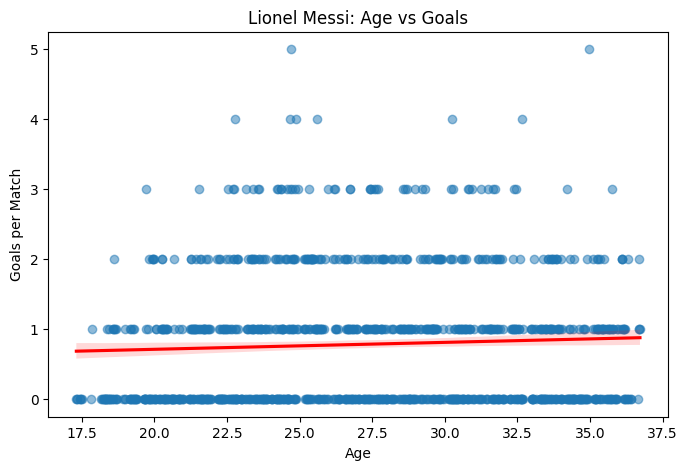

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))


sns.regplot(
    x="Age",
    y="Goals",
    data=df,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)


plt.title("Lionel Messi: Age vs Goals")
plt.xlabel("Age")
plt.ylabel("Goals per Match")


plt.show()

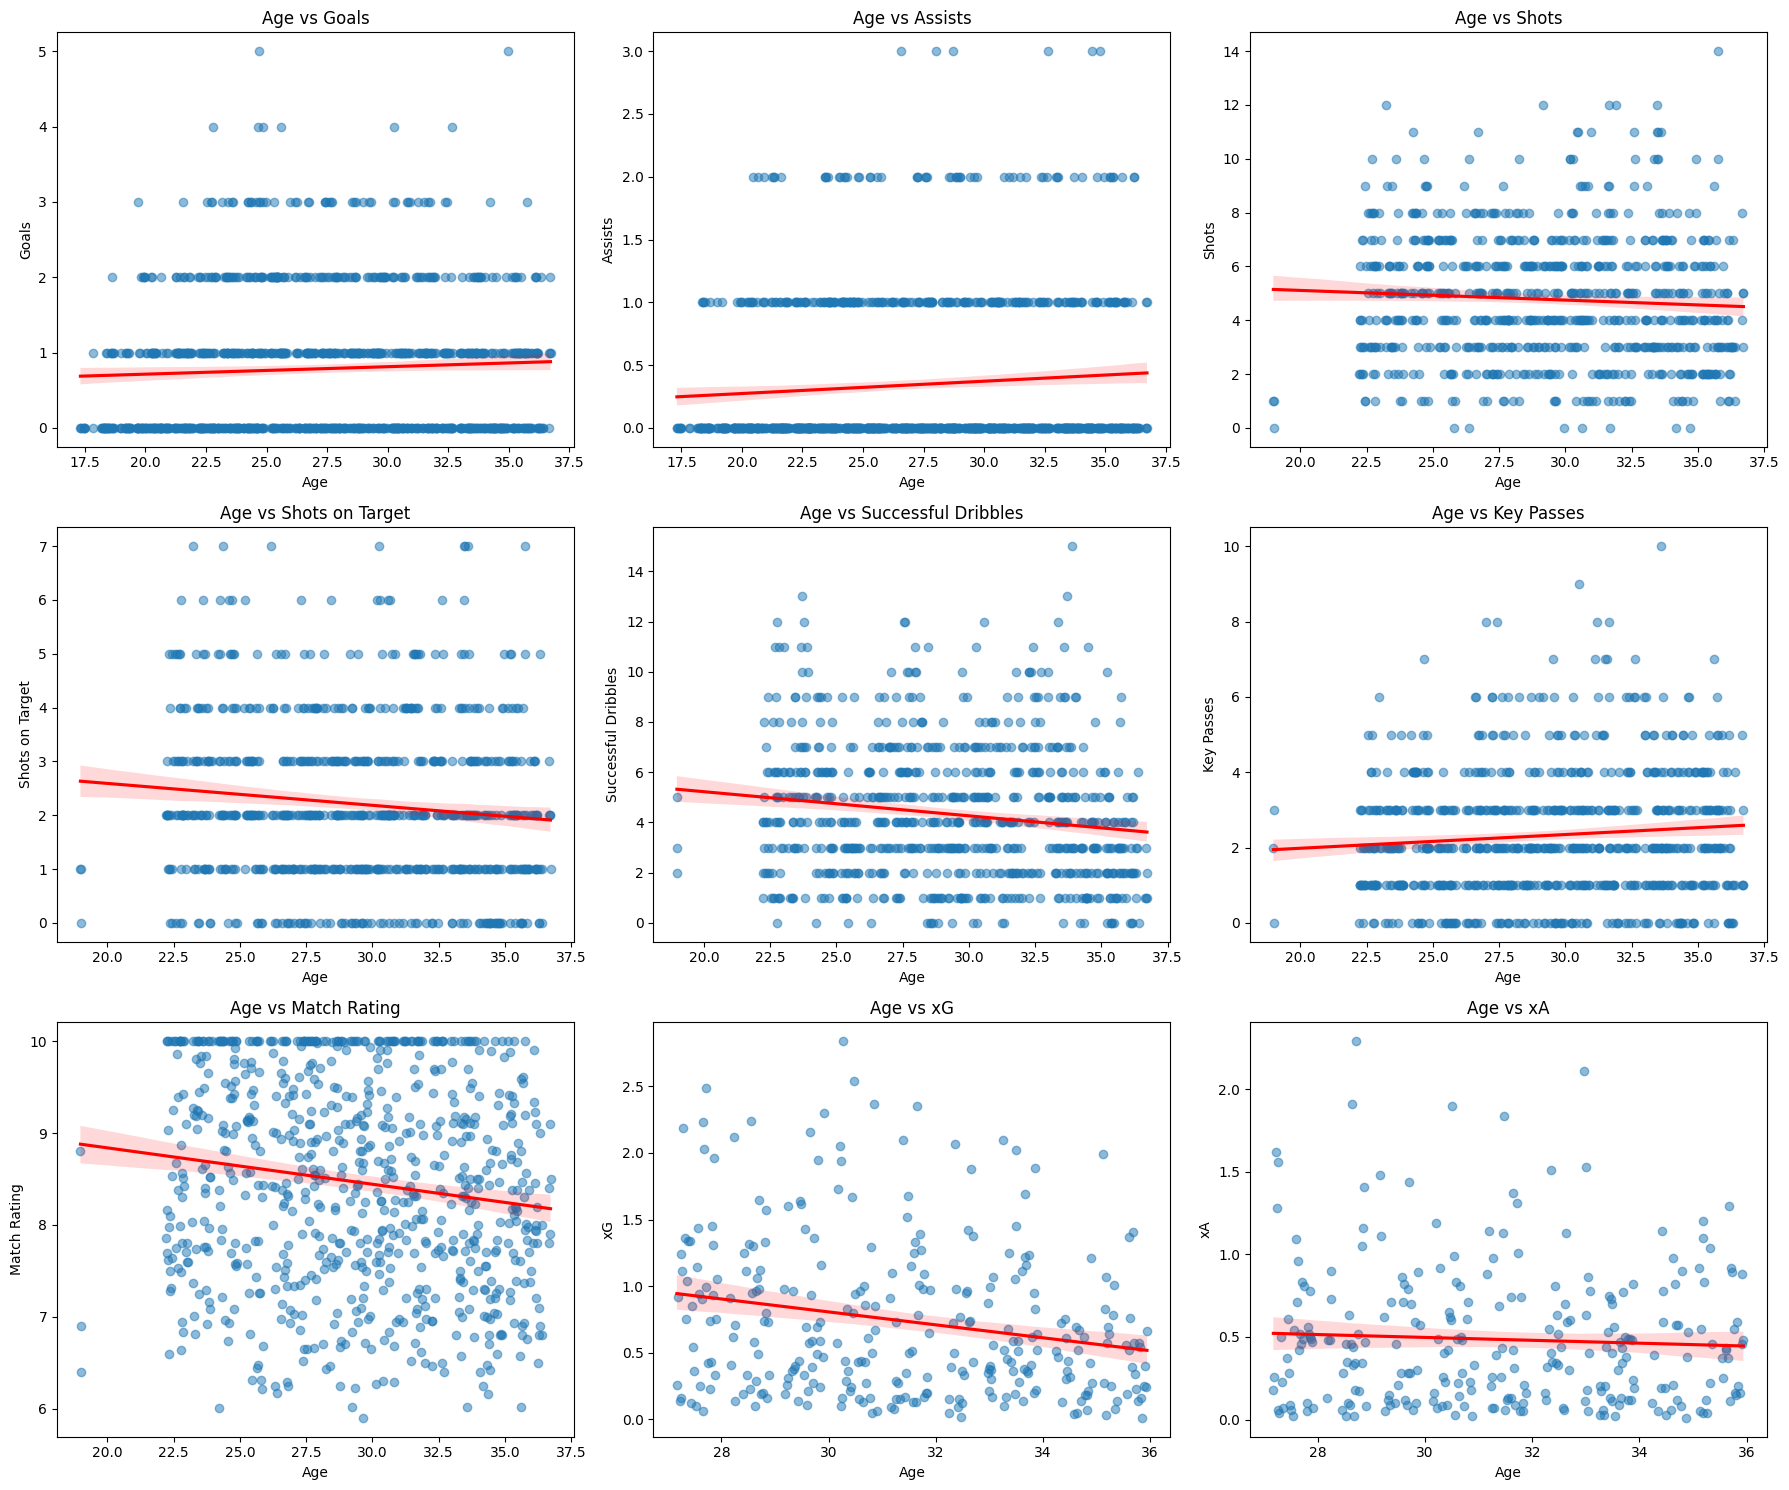

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt


stats = [
    "Goals",
    "Assists",
    "Shots",
    "Shots on Target",
    "Successful Dribbles",
    "Key Passes",
    "Match Rating",
    "xG",
    "xA"
]


fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()


for i, stat in enumerate(stats):
    sns.regplot(
        x="Age",
        y=stat,
        data=df,
        ax=axes[i],
        scatter_kws={"alpha": 0.5},
        line_kws={"color": "red"}
    )
    axes[i].set_title(f"Age vs {stat}")
    axes[i].set_xlabel("Age")
    axes[i].set_ylabel(stat)


plt.tight_layout()
plt.show()